# 2. projekt


Oldja meg a következő kezdeti érték feladatot az RK4 módszerrel $10,20,50$ lépést használva. Ábrázolja a kapott közelítéseket az `ode45` által számolt eredménnyel közös ábrákon.
$$
\begin{gather*}
y'=\sin(2y)+\frac{\cos(t)}{t^2+2} \\
y(1)=2\\
y(7)=?
\end{gather*}
$$


## RK4

In [1]:
%%file "RK4.m"

function [t, y] = RK4(f, tspan, y0, L)
  t = linspace(tspan(1), tspan(2), L+1);
  h = t(2)-t(1);
  y = zeros(size(t));
  y(1) = y0;
  for it=2:L+1
    k1 = f(t(it-1), y(it-1));
    k2 = f(t(it-1)+0.5*h, y(it-1)+0.5*h*k1);
    k3 = f(t(it-1)+0.5*h, y(it-1)+0.5*h*k2);
    k4 = f(t(it-1)+h, y(it-1)+h*k3);
    y(it) = y(it-1) + h*(k1 + 2*k2 + 2*k3 + k4)/6;
  end
end


Created file '/home/nosy/Downloads/mm2_projektek/p2/RK4.m'.


In [4]:
f = @(t,y) sin(2*y) + cos(t) ./ (t.^2 + 2);
t0 = 1; tv = 7; y0 = 0;
tspan = [t0, tv];
[t10, y10] = RK4(f, tspan, y0, 10);
[t20, y20] = RK4(f, tspan, y0, 20);


[t45,y45] = ode45(f, tspan, y0);


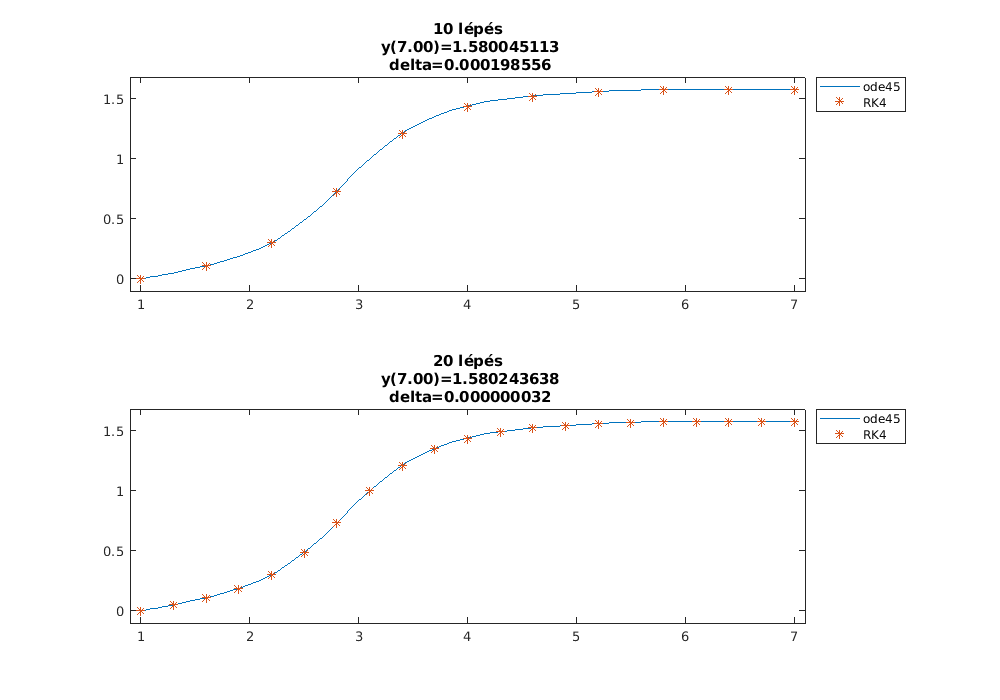

In [7]:
%plot -s 1000,700

% külön abrakat használva jobban látszik a módszer dinamikája

% ez ciklusban szebb lenne
subplot(2,1,1);
plot(t45, y45, t10, y10, "*");
elteres = abs(y45(end)-y10(end));
legend("ode45", "RK4", "Location", "northeastoutside");
title(sprintf("10 lépés\n y(%.2f)=%.9f\n delta=%.9f", tv, y10(end),elteres));
xlim([t0-0.1, tv+0.1]);
ylim([min(min(y45),min(y10))-0.1, max(max(y45),max(y10))+0.1]);

subplot(2,1,2);
plot(t45, y45, t20, y20, "*");
elteres = abs(y45(end)-y20(end));
legend("ode45", "RK4", "Location", "northeastoutside");
title(sprintf("20 lépés\n y(%.2f)=%.9f\n delta=%.9f", tv, y20(end),elteres));
xlim([t0-0.1, tv+0.1]);
ylim([min(min(y45),min(y20))-0.1, max(max(y45),max(y20))+0.1]);


